# Statistical Modeling and Air Quality Prediction Using Beijing Multi-Site Data

## Introduction

This project analyzes air pollution patterns in Beijing using air quality and meteorological data collected from 12 monitoring stations between March 2013 and February 2017. The objective is to understand factors influencing air pollution levels and develop statistical models to predict PM2.5 concentrations using weather-related variables.

PM2.5 was selected as the primary target variable because it is a widely used indicator of air quality, exhibits substantial variation across seasons and locations, and is well suited for statistical analysis and predictive modeling.

## Dataset Overview

Dataset: Beijing Multi-Site Air Quality Dataset (UCI Repository)

Time Period:
- March 2013 – February 2017

Monitoring Stations:
- 12 stations across Beijing

Total Records:
- 420,768 hourly observations

Air Quality Variables:
- PM2.5
- PM10
- SO2
- NO2
- CO
- O3

Meteorological Variables:
- Temperature (TEMP)
- Pressure (PRES)
- Dew Point (DEWP)
- Rainfall (RAIN)
- Wind Speed (WSPM)
- Wind Direction (wd)

# Data Preparation and Cleaning 


## 1. Import Libraries and Load Raw Data

In [156]:
import pandas as pd
import glob
import os
from pathlib import Path

base_dir = "../datasets/raw"

csv_files = [
    file for file in os.listdir(base_dir)
    if file.endswith(".csv") and file.startswith("PRSA_Data")
]

print("Number of station files:", len(csv_files))
print(sorted(csv_files))

Number of station files: 12
['PRSA_Data_Aotizhongxin_20130301-20170228.csv', 'PRSA_Data_Changping_20130301-20170228.csv', 'PRSA_Data_Dingling_20130301-20170228.csv', 'PRSA_Data_Dongsi_20130301-20170228.csv', 'PRSA_Data_Guanyuan_20130301-20170228.csv', 'PRSA_Data_Gucheng_20130301-20170228.csv', 'PRSA_Data_Huairou_20130301-20170228.csv', 'PRSA_Data_Nongzhanguan_20130301-20170228.csv', 'PRSA_Data_Shunyi_20130301-20170228.csv', 'PRSA_Data_Tiantan_20130301-20170228.csv', 'PRSA_Data_Wanliu_20130301-20170228.csv', 'PRSA_Data_Wanshouxigong_20130301-20170228.csv']


## 2. Combine Station-Level Datasets

In [157]:
dataframes = []

#concat all station files into a single DataFrame

for file in csv_files:
    file_path = os.path.join(base_dir, file)

    temp_df = pd.read_csv(file_path)

    station_name = (
        file.replace("PRSA_Data_", "")
            .replace("_20130301-20170228.csv", "")
    )

    temp_df["station"] = station_name

    dataframes.append(temp_df)

df = pd.concat(dataframes, ignore_index=True)


print("Shape:", df.shape)

print("\nNumber of stations:")
print(df["station"].nunique())

print("\nRows per station:")
print(df["station"].value_counts())

Shape: (420768, 18)

Number of stations:
12

Rows per station:
station
Aotizhongxin     35064
Changping        35064
Dingling         35064
Dongsi           35064
Guanyuan         35064
Gucheng          35064
Huairou          35064
Nongzhanguan     35064
Shunyi           35064
Tiantan          35064
Wanliu           35064
Wanshouxigong    35064
Name: count, dtype: int64


## 3. Save Combined Dataset

In [158]:
# save the combined DataFrame to a new CSV file
df.to_csv(
    "../datasets/processed/beijing_air_quality_combined.csv",
    index=False
)

## 4. Create Datetime Feature


In [159]:
# Create a datetime column from year, month, day, hour
df["datetime"] = pd.to_datetime(
    df[["year", "month", "day", "hour"]]
)

## 5. Dataset Overview


In [160]:

df.describe().round(2)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,datetime
count,420768.00,420768.00,420768.00,420768.00,420768.00,412029.00,414319.00,411747.00,408652.00,400067.00,407491.00,420370.00,420375.00,420365.00,420378.00,420450.00,420768
mean,17532.50,2014.66,6.52,15.73,11.50,79.79,104.60,15.83,50.64,1230.77,57.37,13.54,1010.75,2.49,0.06,1.73,2015-03-01 11:30:00
min,1.00,2013.00,1.00,1.00,0.00,2.00,2.00,0.29,1.03,100.00,0.21,-19.90,982.40,-43.40,0.00,0.00,2013-03-01 00:00:00
25%,8766.75,2014.00,4.00,8.00,5.75,20.00,36.00,3.00,23.00,500.00,11.00,3.10,1002.30,-8.90,0.00,0.90,2014-03-01 05:45:00
50%,17532.50,2015.00,7.00,16.00,11.50,55.00,82.00,7.00,43.00,900.00,45.00,14.50,1010.40,3.10,0.00,1.40,2015-03-01 11:30:00
75%,26298.25,2016.00,10.00,23.00,17.25,111.00,145.00,20.00,71.00,1500.00,82.00,23.30,1019.00,15.10,0.00,2.20,2016-02-29 17:15:00
max,35064.00,2017.00,12.00,31.00,23.00,999.00,999.00,500.00,290.00,10000.00,1071.00,41.60,1042.80,29.10,72.50,13.20,2017-02-28 23:00:00
std,10122.12,1.18,3.45,8.80,6.92,80.82,91.77,21.65,35.13,1160.18,56.66,11.44,10.47,13.79,0.82,1.25,NaN


## 6. Data Type and Structure Review


In [161]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Stations:", df["station"].nunique())
print("Date Range:")
print(df["datetime"].min())
print(df["datetime"].max())


Rows: 420768
Columns: 19
Stations: 12
Date Range:
2013-03-01 00:00:00
2017-02-28 23:00:00


In [162]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 19 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   No        420768 non-null  int64         
 1   year      420768 non-null  int64         
 2   month     420768 non-null  int64         
 3   day       420768 non-null  int64         
 4   hour      420768 non-null  int64         
 5   PM2.5     412029 non-null  float64       
 6   PM10      414319 non-null  float64       
 7   SO2       411747 non-null  float64       
 8   NO2       408652 non-null  float64       
 9   CO        400067 non-null  float64       
 10  O3        407491 non-null  float64       
 11  TEMP      420370 non-null  float64       
 12  PRES      420375 non-null  float64       
 13  DEWP      420365 non-null  float64       
 14  RAIN      420378 non-null  float64       
 15  wd        418946 non-null  str           
 16  WSPM      420450 non-null  float64       
 17  st

## 7. Missing Value Analysis


In [163]:

# Missing Value Percentage

missing_df = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": round(df.isnull().mean() * 100, 2)
})

missing_df.sort_values(
    by="Missing %",
    ascending=False
)

,Missing Count,Missing %
CO,20701,4.92
O3,13277,3.16
NO2,12116,2.88
SO2,9021,2.14
PM2.5,8739,2.08
PM10,6449,1.53
wd,1822,0.43
DEWP,403,0.10
RAIN,390,0.09
PRES,393,0.09


In [164]:
df.groupby("station")["CO"].apply(
    lambda x: x.isnull().sum()
)

station
Aotizhongxin     1776
Changping        1521
Dingling         2012
Dongsi           3197
Guanyuan         1753
Gucheng          1401
Huairou          1422
Nongzhanguan     1206
Shunyi           2178
Tiantan          1126
Wanliu           1812
Wanshouxigong    1297
Name: CO, dtype: int64

#  Data Exploration, Visualization & Insights

## 8. Station-Level PM2.5 Analysis


### 8.1 Summary Statistics by Station

In [165]:
df.groupby("station")["PM2.5"] \
  .agg(["mean", "median", "std"]) \
  .sort_values("mean", ascending=False)

,mean,median,std
station,,,
Dongsi,86.194297,61.0,86.575127
Wanshouxigong,85.024136,60.0,85.975981
Nongzhanguan,84.838483,59.0,86.225344
Gucheng,83.852089,60.0,82.796445
Wanliu,83.374716,59.0,81.905568
Guanyuan,82.933372,59.0,80.933497
Aotizhongxin,82.773611,58.0,82.135694
Tiantan,82.164911,59.0,80.921384
Shunyi,79.491602,55.0,81.231739


### 8.2 Average PM2.5 Concentration by Station

<Axes: xlabel='station'>

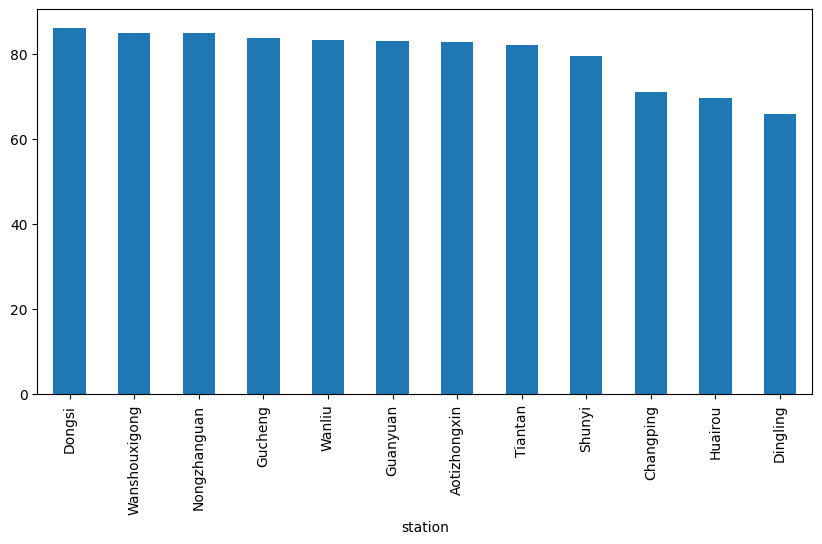

In [166]:
station_pm25 = (
    df.groupby("station")["PM2.5"]
      .mean()
      .sort_values(ascending=False)
)

station_pm25.plot(
    kind="bar",
    figsize=(10,5)
)

### 8.3 Distribution of PM2.5 Levels

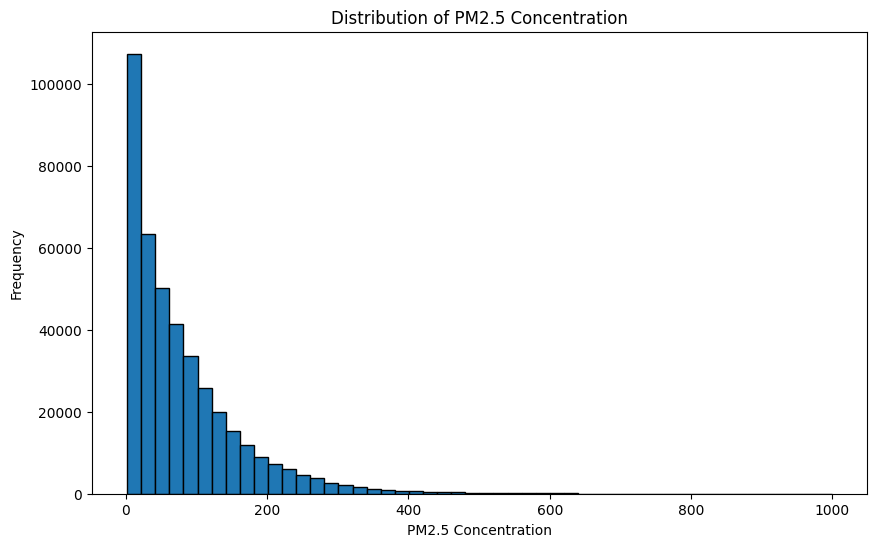

PM2.5 summary statistics:


count    412029.00
mean         79.79
std          80.82
min           2.00
25%          20.00
50%          55.00
75%         111.00
max         999.00
Name: PM2.5, dtype: float64

In [167]:
# Distribution of PM2.5

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df["PM2.5"], bins=50, edgecolor="black")
plt.xlabel("PM2.5 Concentration")
plt.ylabel("Frequency")
plt.title("Distribution of PM2.5 Concentration")
plt.show()

print("PM2.5 summary statistics:")
display(df["PM2.5"].describe().round(2))

The PM2.5 distribution is right-skewed, with most observations concentrated at lower values and a small number of extreme pollution events at higher concentrations. The mean exceeds the median, confirming the presence of positive skewness.

## 9. Seasonal PM2.5 Analysis


### 9.1 Summary Statistics by Season

In [168]:
# Feature Engineering: Create a new column for season based on the month

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df["season"] = df["month"].apply(get_season)

df.groupby("season")["PM2.5"] \
  .agg(["count", "mean", "median", "std"])

,count,mean,median,std
season,,,,
Fall,102746,82.332246,56.0,81.439916
Spring,103705,76.973508,58.0,68.827786
Summer,103671,64.674881,51.0,52.649627
Winter,101907,95.483630,56.0,107.657567


### 9.2 Average PM2.5 by Season

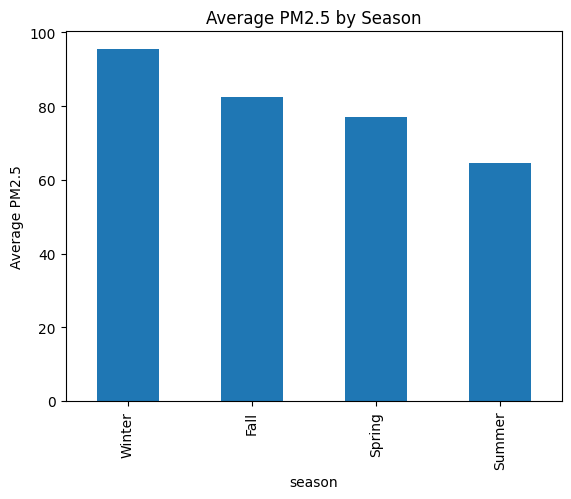

In [169]:
import matplotlib.pyplot as plt

season_pm25 = (
    df.groupby("season")["PM2.5"]
      .mean()
      .sort_values(ascending=False)
)

season_pm25.plot(kind="bar")
plt.title("Average PM2.5 by Season")
plt.ylabel("Average PM2.5")
plt.show()

### 9.3 PM2.5 Distribution by Season

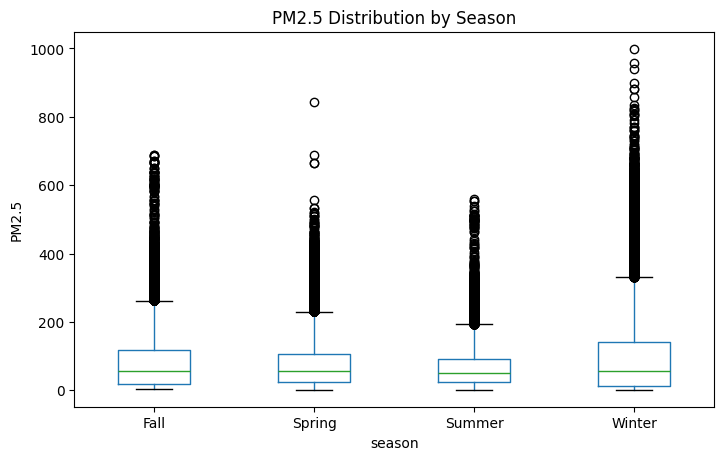

In [170]:
import matplotlib.pyplot as plt

df.boxplot(
    column="PM2.5",
    by="season",
    figsize=(8,5),
    grid=False
)

plt.title("PM2.5 Distribution by Season")
plt.suptitle("")
plt.ylabel("PM2.5")
plt.show()

## 10. Correlation Analysis


### 10.1 Correlation Heatmap

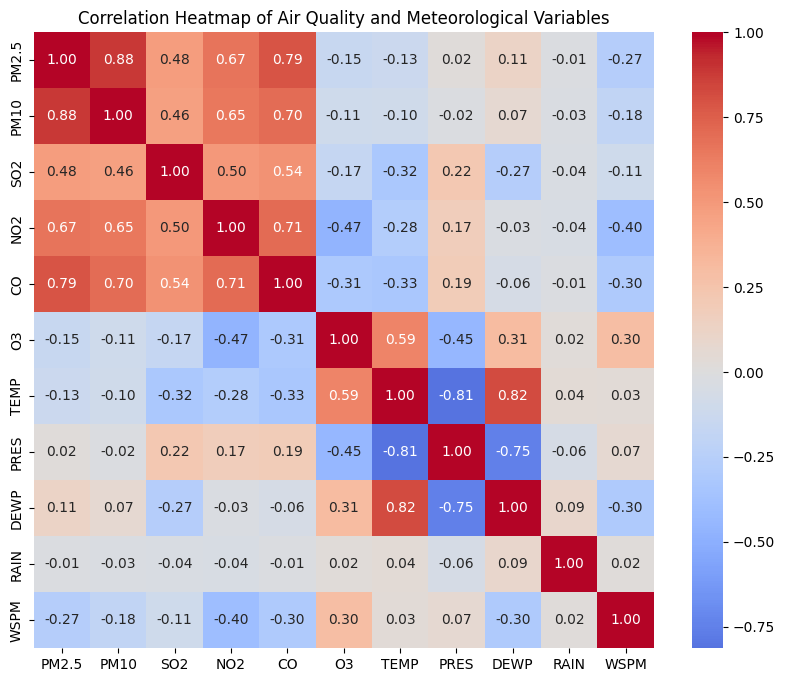

In [171]:
import seaborn as sns
import matplotlib.pyplot as plt

pollution_columns = [
    "PM2.5",
    "PM10",
    "SO2",
    "NO2",
    "CO",
    "O3",
    "TEMP",
    "PRES",
    "DEWP",
    "RAIN",
    "WSPM"
]

corr = df[pollution_columns].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Air Quality and Meteorological Variables")
plt.show()

Major relationships identified:

PM2.5 and PM10: 0.88

PM2.5 and CO: 0.79

PM2.5 and NO2: 0.67

PM2.5 and Wind Speed (WSPM): -0.27

These findings suggest pollutant concentrations are strongly related, while higher wind speeds are associated with lower PM2.5 levels.


### 10.2 PM2.5 and Wind Speed Relationship

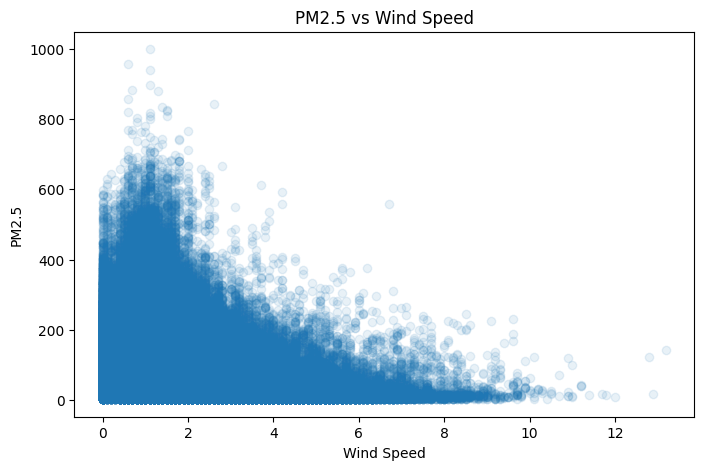

In [172]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["WSPM"],
    df["PM2.5"],
    alpha=0.1
)

plt.xlabel("Wind Speed")
plt.ylabel("PM2.5")
plt.title("PM2.5 vs Wind Speed")

plt.show()

Severe pollution episodes occur primarily during low wind conditions.

High wind speeds appear to reduce the likelihood of extreme PM2.5 events.


## 11. Time-Series Analysis

### 11.1 Monthly PM2.5 Trend by Year

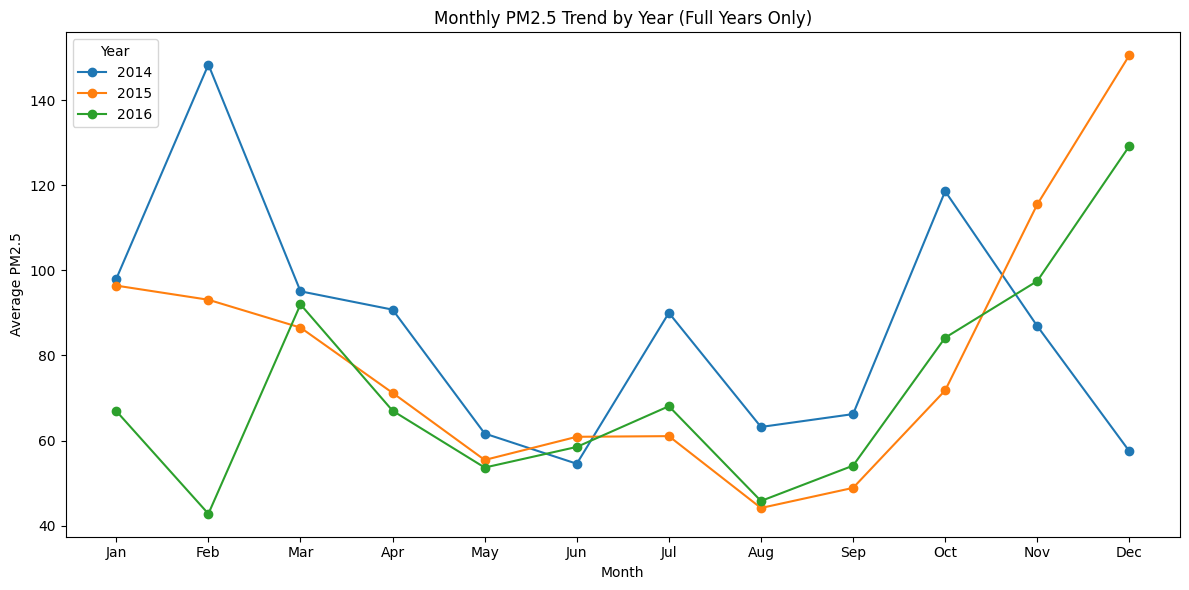

In [173]:
import matplotlib.pyplot as plt

# Use only full years for fair year-over-year comparison
plot_df = df[df["year"].isin([2014, 2015, 2016])]

monthly_yearly = (
    plot_df.groupby(["year", "month"])["PM2.5"]
    .mean()
    .reset_index()
)

months = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(12, 6))

for year in sorted(monthly_yearly["year"].unique()):
    temp = monthly_yearly[monthly_yearly["year"] == year]

    plt.plot(
        temp["month"],
        temp["PM2.5"],
        marker="o",
        label=str(year)
    )

plt.xticks(range(1, 13), months)
plt.xlabel("Month")
plt.ylabel("Average PM2.5")
plt.title("Monthly PM2.5 Trend by Year (Full Years Only)")
plt.legend(title="Year")
plt.tight_layout()
plt.show()

Consistent pollution peaks during winter months.

Lower pollution levels during summer months.

Strong recurring seasonal patterns across years.

Seasonal variation appears to have a stronger impact on PM2.5 than year-to-year variation.


## 12. Missing Value Treatment

#### Numerical columns are imputed with median

In [174]:
numeric_cols = [
    "PM2.5",
    "PM10",
    "SO2",
    "NO2",
    "CO",
    "O3",
    "TEMP",
    "PRES",
    "DEWP",
    "RAIN",
    "WSPM"
]

In [175]:
df_clean = df.copy()

for col in numeric_cols:
    df_clean[col] = (
        df_clean.groupby("station")[col]
        .transform(lambda x: x.fillna(x.median()))
    )

#### Categorical columns are filled with the mode

In [176]:
# Categorical columns can be filled with the mode

df_clean["wd"] = (
    df_clean.groupby("station")["wd"]
    .transform(
        lambda x: x.fillna(x.mode().iloc[0])
    )
)

Numerical missing values were imputed using station-level medians because pollutant variables are right-skewed and contain extreme values. Missing wind direction values were imputed using the station-level mode. Imputation here runs the risk of data leakage, but it was done for the sake of dataset consistency during model comparison. 

In [177]:
# Check for null values after imputation
df_clean.isnull().sum().sort_values(ascending=False)

No          0
year        0
month       0
day         0
hour        0
PM2.5       0
PM10        0
SO2         0
NO2         0
CO          0
O3          0
TEMP        0
PRES        0
DEWP        0
RAIN        0
wd          0
WSPM        0
station     0
datetime    0
season      0
dtype: int64

In [178]:
#copy the cleaned dataframe to a new CSV file for further analysis and modeling

df_clean.to_csv(
    "../datasets/processed/beijing_air_quality_clean.csv",
    index=False
)

In [179]:
df_clean.sample(5)

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime,season
342748,27173,2016,4,6,4,67.0,101.0,45.0,68.0000,2300.0,37.0,10.8,1007.9,-3.7,0.0,ESE,1.3,Tiantan,2016-04-06 04:00:00,Spring
355807,5168,2013,10,2,7,3.0,7.0,15.0,27.0996,300.0,33.0,16.5,1018.8,4.8,0.0,NNE,1.2,Wanliu,2013-10-02 07:00:00,Fall
74883,4756,2013,9,15,3,3.0,6.0,1.0,19.0000,100.0,43.0,16.0,1005.1,5.9,0.0,ENE,1.2,Dingling,2013-09-15 03:00:00,Fall
201930,26611,2016,3,13,18,15.0,29.0,3.0,15.0000,400.0,92.0,11.4,1015.0,-17.1,0.0,W,1.1,Gucheng,2016-03-13 18:00:00,Spring
319201,3626,2013,7,30,1,90.0,80.0,3.0,66.0000,900.0,13.0,24.8,993.9,23.4,0.0,E,0.5,Tiantan,2013-07-30 01:00:00,Summer


## 13. Statistical Tests

### 1) Do PM2.5 concentrations differ significantly across seasons?

#### One Way ANOVA

In [180]:
from scipy.stats import f_oneway

winter = df_clean[df_clean["season"]=="Winter"]["PM2.5"]
spring = df_clean[df_clean["season"]=="Spring"]["PM2.5"]
summer = df_clean[df_clean["season"]=="Summer"]["PM2.5"]
fall   = df_clean[df_clean["season"]=="Fall"]["PM2.5"]

f_stat, p_value = f_oneway(
    winter,
    spring,
    summer,
    fall
)

print(f"F-statistic: {f_stat:.2f}")
print(f"P-value: {p_value:.2f}")

F-statistic: 2617.12
P-value: 0.00


Exploratory analysis indicated that average PM2.5 concentrations varied across seasons, with winter exhibiting the highest pollution levels and summer exhibiting the lowest. To determine whether these observed differences were statistically significant, a one-way ANOVA test was conducted. The results showed a statistically significant difference in PM2.5 concentrations across seasons (F = 2617.12, p < 0.001). Therefore, we reject the null hypothesis and conclude that season has a significant effect on PM2.5 levels.

### 2) Is wind speed associated with PM2.5?

#### Pearson Correlation Significance Test

In [181]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(
    df_clean["PM2.5"],
    df_clean["WSPM"]
)

print(f"Corr: {corr:.2f}")
print(f"P-value: {p_value:.2f}")

Corr: -0.27
P-value: 0.00


A Pearson correlation analysis was conducted to examine the relationship between wind speed (WSPM) and PM2.5 concentrations. Results showed a statistically significant negative correlation (r = -0.27, p < 0.001), indicating that higher wind speeds are generally associated with lower PM2.5 concentrations. This finding supports the hypothesis that stronger winds help disperse airborne pollutants and reduce particulate matter concentrations.

## 14. Model Selection


For the purpose of predicting PM2.5 concentrations, various regression and classification models are trained and compared using the cleaned dataset produced in the preparation phase above.

Two prediction scenarios are evaluated:

- **Nowcasting** — uses highly-correlated pollutant features (SO2, NO2, CO, O3) alongside meteorological data
- **Forecasting** — uses only meteorological data, reflecting the practical case where pollutant readings are unavailable

PM10 is excluded from both feature sets because its correlation with PM2.5 is too high (~0.88) and would trivially dominate any model.

In [182]:
import numpy as np

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, confusion_matrix,
)
import xgboost as xgb

RANDOM_STATE = 42

In [183]:
POLLUTANT_FEATURES = ["SO2", "NO2", "CO", "O3"]
WEATHER_FEATURES = ["TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
TIME_FEATURES = ["hour_sin", "hour_cos", "month_sin", "month_cos"]

FEATURE_SETS = {
    "Pollutants + weather (nowcast)": POLLUTANT_FEATURES + WEATHER_FEATURES + TIME_FEATURES,
    "Weather only (forecast)": WEATHER_FEATURES + TIME_FEATURES,
}

STATIONS = df_clean["station"].unique()

SCOPES = {"All stations": None}
SCOPES.update({f"{station} only": station for station in STATIONS})

# Edges for AQI are arbitrary, so some data leakage here is considered acceptable.
_, QUINTILE_EDGES = pd.qcut(df_clean["PM2.5"], q=5, retbins=True, duplicates="drop")
QUINTILE_EDGES[0], QUINTILE_EDGES[-1] = -np.inf, np.inf
_, BINARY_EDGES = pd.qcut(df_clean["PM2.5"], q=2, retbins=True, duplicates="drop")
BINARY_EDGES [0], BINARY_EDGES [-1] = -np.inf, np.inf

print(f"Quintile Edges: {QUINTILE_EDGES}")
print(f"Binary Edges: {BINARY_EDGES}")

Quintile Edges: [-inf  16.  41.  72. 127.  inf]
Binary Edges: [-inf  55.  inf]


### Feature Engineering
Converts raw date/time into circular coordinates to preserve relationships. 

In [184]:
df_model = df_clean.copy()
df_model = df_model.sort_values(["station", "datetime"]).reset_index(drop=True)

df_model["hour_sin"]   = np.sin(2 * np.pi * df_model["hour"]  / 24)
df_model["hour_cos"]   = np.cos(2 * np.pi * df_model["hour"]  / 24)
df_model["month_sin"]  = np.sin(2 * np.pi * df_model["month"] / 12)
df_model["month_cos"]  = np.cos(2 * np.pi * df_model["month"] / 12)

df_model = pd.get_dummies(df_model, columns=["station"], drop_first=False, dtype=int)

print(f"df_model shape: {df_model.shape}")
print(f"date range: {df_model['datetime'].min()} to {df_model['datetime'].max()}")
print(df_model.columns)

df_model shape: (420768, 35)
date range: 2013-03-01 00:00:00 to 2017-02-28 23:00:00
Index(['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2',
       'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'datetime',
       'season', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
       'station_Aotizhongxin', 'station_Changping', 'station_Dingling',
       'station_Dongsi', 'station_Guanyuan', 'station_Gucheng',
       'station_Huairou', 'station_Nongzhanguan', 'station_Shunyi',
       'station_Tiantan', 'station_Wanliu', 'station_Wanshouxigong'],
      dtype='str')


### Prepare Dataset for Model
`prepare_dataset()` has three functions:
- Splits train/test for model training
- Bins feature (PM2.5) for quintile and binary classifiers 

In [185]:
def prepare_dataset(df, feature_cols, station=None, train_frac=0.8):
    # station=None pools every station together, or takes a station name to restrict model to that subset
    station_cols = [c for c in df.columns if c.startswith("station_")]
    if station is None:
        data = df
        model_features = feature_cols + station_cols
    else:
        data = df[df[f"station_{station}"] == 1].drop(columns=station_cols)
        model_features = feature_cols

    data = data.sort_values("datetime").reset_index(drop=True)
    cutoff = data["datetime"].quantile(train_frac)
    train_mask = data["datetime"] < cutoff

    X_train = data.loc[train_mask, model_features].reset_index(drop=True)
    X_test = data.loc[~train_mask, model_features].reset_index(drop=True)
    y_train = data.loc[train_mask, "PM2.5"].reset_index(drop=True)
    y_test = data.loc[~train_mask, "PM2.5"].reset_index(drop=True)

    # quintile PM2.5 split for classifiers
    labels = [f"Q{i + 1}" for i in range(len(QUINTILE_EDGES) - 1)]
    y_train_cls = pd.cut(y_train, bins=QUINTILE_EDGES, labels=labels)
    y_test_cls = pd.cut(y_test, bins=QUINTILE_EDGES, labels=labels)

    # binary PM2.5 split for binary classifiers
    labels = [f"H{i + 1}" for i in range(len(BINARY_EDGES) - 1)]
    y_train_binary = pd.cut(y_train, bins=BINARY_EDGES, labels=labels)
    y_test_binary = pd.cut(y_test, bins=BINARY_EDGES, labels=labels)

    return {
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test,
        "y_train_cls": y_train_cls, "y_test_cls": y_test_cls,
        "y_train_binary": y_train_binary, "y_test_binary": y_test_binary,
        "n_train": int(train_mask.sum()), "n_test": int((~train_mask).sum()),
        "test_start": data.loc[~train_mask, "datetime"].min(),
        "test_end": data.loc[~train_mask, "datetime"].max(),
    }


## Candidate Models

**OLS (Linear Regression)**
- Assumes a linear relationship between features and PM2.5
- Assumes independent observations
- Assumes no multicollinearity
- Uses scaling

**Random Forest**
- Assumes independent observations
- Allows multicollinearity
- Used for both regression and classification tasks

**XGBoost**
- Allows multicollinearity
- Can technically handle missing data but for the sake of model comparison, the same train and test sets are used for all models
- Used for both regression and classification tasks

**Logistic Regression**
- Assumes independent observations
- Assumes no multicollinearity
- Uses scaling

**Naive Bayes**
- Assumes conditional independence of features
- Uses scaling

In [ ]:
def run_regressors(split):
    models = {
        "OLS": Pipeline([
                ("scale", StandardScaler()),
                ("model", LinearRegression()),
            ]),
        "Random Forest": RandomForestRegressor(
            n_estimators=150, n_jobs=-1, random_state=RANDOM_STATE
        ),
        "XGBoost": xgb.XGBRegressor(
            n_estimators=300, learning_rate=0.05, max_depth=4,
            subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=-1,
        ),
    }
    
    station_cols = [col for col in split["X_test"].columns if col.startswith("station_")]

    rows, fitted = {}, {}
    for name, model in models.items():
        model.fit(split["X_train"], split["y_train"])
        preds = model.predict(split["X_test"])
        rows[name] = {
            "RMSE": np.sqrt(mean_squared_error(split["y_test"], preds)),
            "MAE": mean_absolute_error(split["y_test"], preds),
            "R2": r2_score(split["y_test"], preds),
            "station": {}
        }
        for col in station_cols:
            if col in split["X_test"].columns and (split["X_test"][col] == 1).any():
                mask = split["X_test"][col] == 1
                station_name = col.replace("station_", "")
                
                rows[name]["station"][station_name] = {
                        "RMSE": np.sqrt(mean_squared_error(split["y_test"][mask], preds[mask])),
                        "MAE": mean_absolute_error(split["y_test"][mask], preds[mask]),
                        "R2": r2_score(split["y_test"][mask], preds[mask]),
                    }
        fitted[name] = model
    return pd.DataFrame(rows).T.sort_values("RMSE"), fitted

In [ ]:
def run_classifiers(split):
    label_encoder = LabelEncoder()
    y_train_enc = label_encoder.fit_transform(split["y_train_cls"])
    y_test_enc = label_encoder.transform(split["y_test_cls"])

    models = {
        "Logistic Regression": Pipeline([
                ("scale", StandardScaler()),
                ("model", LogisticRegression(max_iter=1000)),
            ]),
        "Naive Bayes":  Pipeline([
                ("scale", StandardScaler()),
                ("model", GaussianNB()),
            ]),
        "Random Forest": RandomForestClassifier(
            n_estimators=150, n_jobs=-1, max_depth=4, random_state=RANDOM_STATE
        ),
        "XGBoost": xgb.XGBClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=4,
            subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
            n_jobs=-1, eval_metric="mlogloss",
        ),
    }

    station_cols = [col for col in split["X_test"].columns if col.startswith("station_")]

    rows, fitted = {}, {}
    for name, model in models.items():
        model.fit(split["X_train"], y_train_enc)
        preds = model.predict(split["X_test"])
        rows[name] = {
            "Accuracy": accuracy_score(y_test_enc, preds),
            "F1_weighted": f1_score(y_test_enc, preds, average="weighted"),
            "station": {}
        }
        for col in station_cols:
            if col in split["X_test"].columns and (split["X_test"][col] == 1).any():
                mask = split["X_test"][col] == 1
                station_name = col.replace("station_", "")
                
                rows[name]["station"][station_name] = {
                        "Accuracy": accuracy_score(y_test_enc[mask], preds[mask]),
                        "F1_weighted": f1_score(y_test_enc[mask], preds[mask], average="weighted"),
                    }
        fitted[name] = model
    return pd.DataFrame(rows).T.sort_values("Accuracy", ascending=False), fitted, label_encoder

In [ ]:
def run_binary_classifiers(split):
    label_encoder = LabelEncoder()
    y_train_enc = label_encoder.fit_transform(split["y_train_binary"])
    y_test_enc = label_encoder.transform(split["y_test_binary"])

    models = {
        "Logistic Regression": Pipeline([
                ("scale", StandardScaler()),
                ("model", LogisticRegression(max_iter=1000)),
            ]),
        "Naive Bayes":  Pipeline([
                ("scale", StandardScaler()),
                ("model", GaussianNB()),
            ]),
        "Random Forest": RandomForestClassifier(
            n_estimators=150, max_depth=4, n_jobs=-1, random_state=RANDOM_STATE
        ),
        "XGBoost": xgb.XGBClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=4,
            subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
            n_jobs=-1, eval_metric="mlogloss",
        )
    }

    station_cols = [col for col in split["X_test"].columns if col.startswith("station_")]

    rows, fitted = {}, {}
    for name, model in models.items():
        model.fit(split["X_train"], y_train_enc)
        preds = model.predict(split["X_test"])
        rows[name] = {
            "Accuracy": accuracy_score(y_test_enc, preds),
            "F1_weighted": f1_score(y_test_enc, preds, average="weighted"),
            "station": {}
        }
        for col in station_cols:
            if col in split["X_test"].columns and (split["X_test"][col] == 1).any():
                mask = split["X_test"][col] == 1
                station_name = col.replace("station_", "")
                
                rows[name]["station"][station_name]={
                        "Accuracy": accuracy_score(y_test_enc[mask], preds[mask]),
                        "F1_weighted": f1_score(y_test_enc[mask], preds[mask], average="weighted"),
                    }
        fitted[name] = model
    return pd.DataFrame(rows).T.sort_values("Accuracy", ascending=False), fitted, label_encoder

### Run models with basic evaluations

In [189]:
regression_results = {}
classification_results = {}
binary_results = {}
fitted_models = {}
splits = {}

for feature, feature_cols in FEATURE_SETS.items():
    for scope, station in SCOPES.items():
        key = (feature, scope)
        split = prepare_dataset(df_model, feature_cols, station=station)
        reg_table, reg_models = run_regressors(split)
        clf_table, clf_models, label_encoder = run_classifiers(split)
        binary_table, binary_models, binary_label_encoder = run_binary_classifiers(split)
        splits[key] = split

        regression_results[key] = reg_table
        classification_results[key] = clf_table
        binary_results[key] = binary_table

        reg_table = reg_table.drop(columns=['station'], errors='ignore')
        clf_table = clf_table.drop(columns=['station'], errors='ignore')
        binary_table = binary_table.drop(columns=['station'], errors='ignore')

        fitted_models[key] = {
            "regression": reg_models,
            "quintile classification": clf_models,
            "binary classification": binary_models,
            "label_encoder": label_encoder,
            "binary_label_encoder": binary_label_encoder
        }

        print(f"\n=== {feature} | {scope} ===")
        print(f"train rows: {split['n_train']:,} | test rows: {split['n_test']:,} "
              f"(test period {split['test_start'].date()} to {split['test_end'].date()})")
        print("\nRegression:")
        print(reg_table.round(3).to_string())
        print("\nClassification (PM2.5 quintile):")
        print(clf_table.round(3).to_string())
        print("\nClassification (PM2.5 binary):")
        print(binary_table.round(3).to_string())


=== Pollutants + weather (nowcast) | All stations ===
train rows: 336,612 | test rows: 84,156 (test period 2016-05-12 to 2017-02-28)

Regression:
                    RMSE        MAE        R2
Random Forest  38.665789  23.426331  0.780989
XGBoost        38.945363  23.394891   0.77781
OLS            42.079174  27.956388  0.740614

Classification (PM2.5 quintile):
                     Accuracy F1_weighted
XGBoost              0.616213    0.612872
Logistic Regression  0.602025    0.601093
Random Forest        0.566923    0.556346
Naive Bayes          0.483127    0.462009

Classification (PM2.5 binary):
                     Accuracy F1_weighted
XGBoost              0.870146     0.87011
Logistic Regression  0.856612    0.856448
Random Forest        0.844824    0.844838
Naive Bayes          0.769951     0.76414

=== Pollutants + weather (nowcast) | Aotizhongxin only ===
train rows: 28,051 | test rows: 7,013 (test period 2016-05-12 to 2017-02-28)

Regression:
                    RMSE        M

# Model Comparison
The models are comparatively evaluated, using $R^2$ for regression models and accuracy for the classification models. 

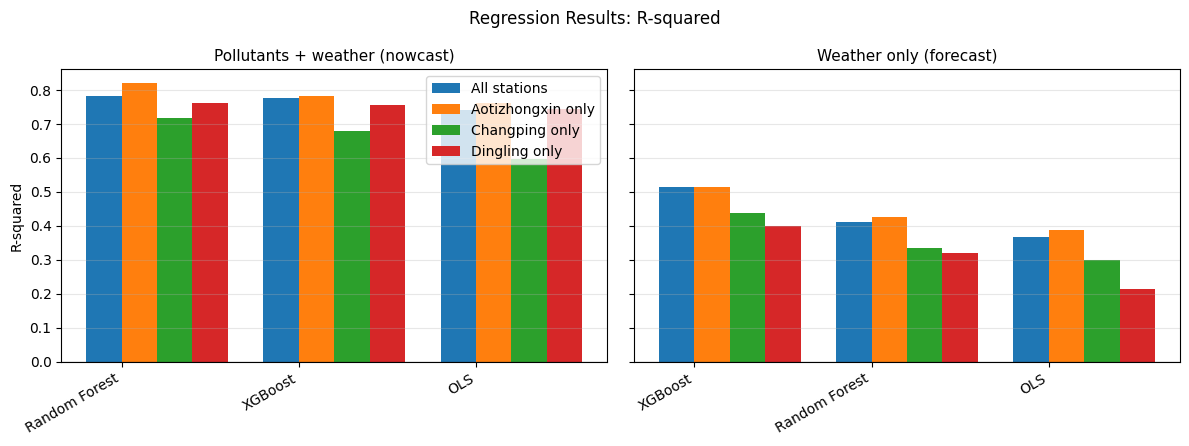

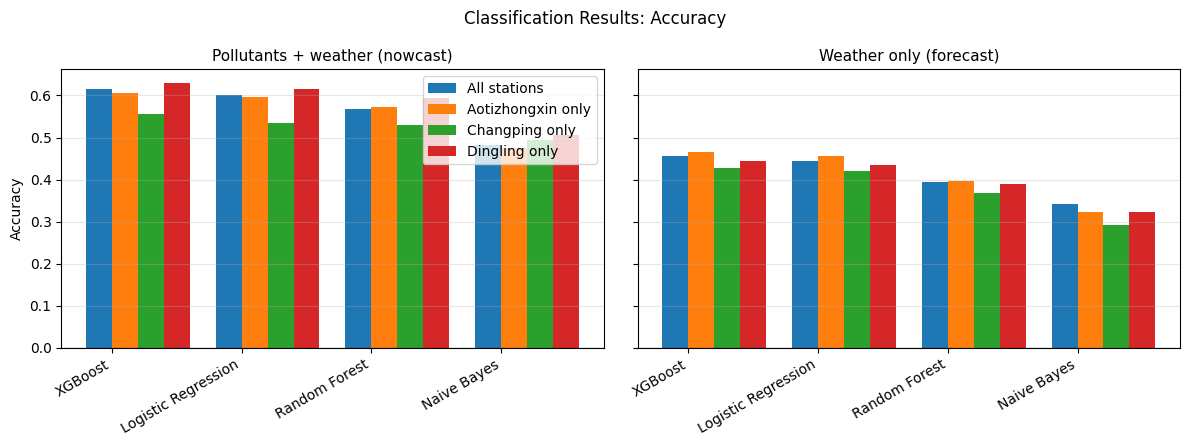

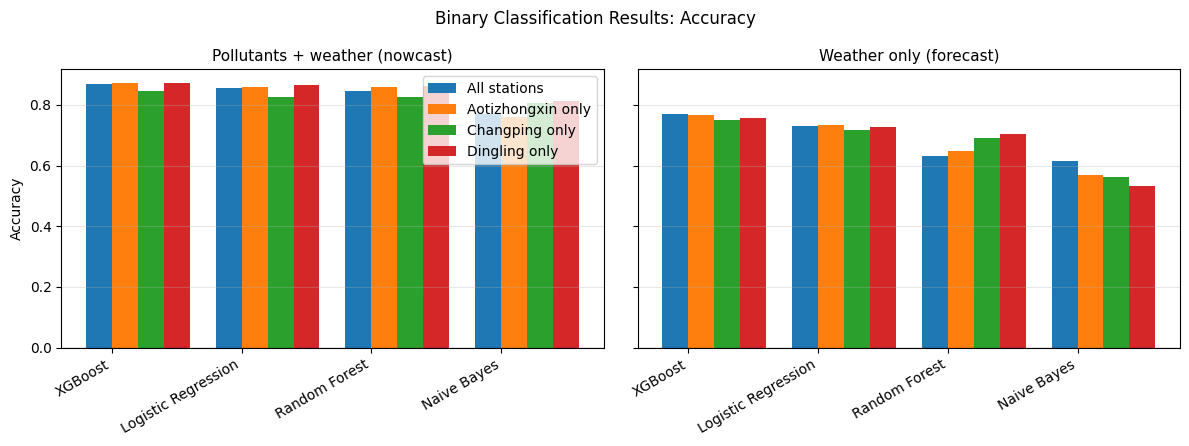

In [190]:
def plot_compare(results, metric, ylabel, title):
    fig, axes = plt.subplots(1, len(FEATURE_SETS), figsize=(6 * len(FEATURE_SETS), 4.5), sharey=True)
    scope_keys = list(SCOPES.keys())
    width = 0.2

    for ax, feature in zip(axes, FEATURE_SETS):
        models = results[(feature, scope_keys[0])].index.tolist()
        x = np.arange(len(models))
        for i, scope in enumerate(scope_keys[0:4]):
            values = results[(feature, scope)][metric].values
            ax.bar(x + i * width, values, width, label=scope)
        ax.set_xticks(x + width / 2)
        ax.set_xticklabels(models, rotation=30, ha="right")
        ax.set_title(feature, fontsize=11)
        ax.grid(axis="y", alpha=0.3)
        ax.axhline(0, color="black", lw=0.8)

    axes[0].set_ylabel(ylabel)
    axes[0].legend()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_compare(regression_results,      "R2",       "R-squared", "Regression Results: R-squared")
plot_compare(classification_results,  "Accuracy", "Accuracy",  "Classification Results: Accuracy")
plot_compare(binary_results,          "Accuracy", "Accuracy",  "Binary Classification Results: Accuracy")

## 15. Model Evaulation
XGBoost outperforms the other models and is chosen for further evaluations.

### 1. Scope Performance
Considers whether the best all-station model outperforms the best single station model on each local station using $R^2$ as the evaluation metric.

In [191]:
def compare_scope_performance(feature, local_scope):
    station_name = SCOPES[local_scope]

    pooled = regression_results[(feature, "All stations")]
    local = regression_results[(feature, f"{station_name} only")]

    # Extract the pooled model's performance at this station
    pooled_local_r2s = pooled['station'].apply(lambda x: x[station_name]['R2'])
    
    pooled_best_model = pooled_local_r2s.idxmax()
    pooled_r2 = pooled_local_r2s.max()

    local_best_model = local["R2"].idxmax()
    local_r2 = local.loc[local_best_model, "R2"]                                         
    
    print(f"{feature}:")
    print(f"  Pooled (Local Eval) -> best R2 = {pooled_r2:.3f} ({pooled_best_model})")
    print(f"  {local_scope:<19} -> best R2 = {local_r2:.3f} ({local_best_model})")
    if local_r2 > pooled_r2: 
        print(f"    Local model is more accurate ({local_best_model})\n")
    elif local_r2 < pooled_r2:    
        print(f"    Pooled model is more accurate ({pooled_best_model})\n")
    else:
        print(f"    Both models are equally accurate\n")

# Call the function passing the raw station name
for feature in FEATURE_SETS:
    for station in STATIONS:
        compare_scope_performance(feature, f"{station} only")

Pollutants + weather (nowcast):
  Pooled (Local Eval) -> best R2 = 0.818 (XGBoost)
  Aotizhongxin only   -> best R2 = 0.820 (XGBoost)
    Local model is more accurate (XGBoost)

Pollutants + weather (nowcast):
  Pooled (Local Eval) -> best R2 = 0.723 (XGBoost)
  Changping only      -> best R2 = 0.717 (OLS)
    Pooled model is more accurate (XGBoost)

Pollutants + weather (nowcast):
  Pooled (Local Eval) -> best R2 = 0.798 (XGBoost)
  Dingling only       -> best R2 = 0.762 (XGBoost)
    Pooled model is more accurate (XGBoost)

Pollutants + weather (nowcast):
  Pooled (Local Eval) -> best R2 = 0.779 (Random Forest)
  Dongsi only         -> best R2 = 0.788 (XGBoost)
    Local model is more accurate (XGBoost)

Pollutants + weather (nowcast):
  Pooled (Local Eval) -> best R2 = 0.728 (XGBoost)
  Guanyuan only       -> best R2 = 0.707 (XGBoost)
    Pooled model is more accurate (XGBoost)

Pollutants + weather (nowcast):
  Pooled (Local Eval) -> best R2 = 0.824 (Random Forest)
  Gucheng only  

### 2. XGBoost Graphs
Multipe graphs are used to evaluate XGBoost's regression model:
- A hexgrid, comparing the actual vs predicted performance.
- Bar charts, comparing the importance of features.

For the classification models:
- Confusion matrices for quintile task.
- Confusion matrices for binary task.

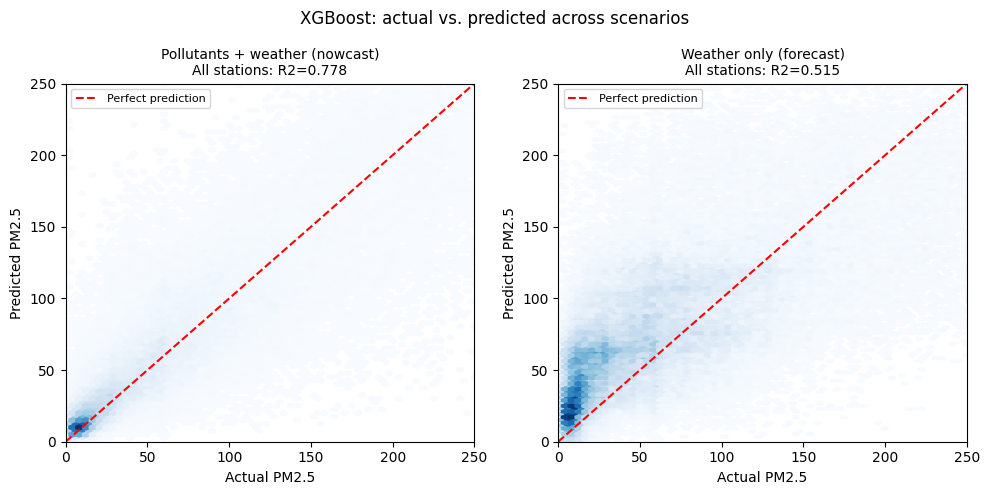

In [192]:
fig, axes = plt.subplots(1,2, figsize=(10, 5))

for ax, feature in zip(axes, FEATURE_SETS):
    scope = "All stations"
    split = splits[(feature, scope)]
    model = fitted_models[(feature, scope)]["regression"]["XGBoost"]
    preds = model.predict(split["X_test"])
    r2 = r2_score(split["y_test"], preds)

    hb = ax.hexbin(split["y_test"], preds, gridsize=200, cmap="Blues", mincnt=1)
    ax.plot([0, 250], [0, 250], "r--", lw=1.5, label="Perfect prediction")
    ax.set_xlim(0, 250)
    ax.set_ylim(0, 250)
    ax.set_xlabel("Actual PM2.5")
    ax.set_ylabel("Predicted PM2.5")
    ax.set_title(f"{feature}\n{scope}: R2={r2:.3f}", fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle("XGBoost: actual vs. predicted across scenarios")
plt.tight_layout()
plt.show()

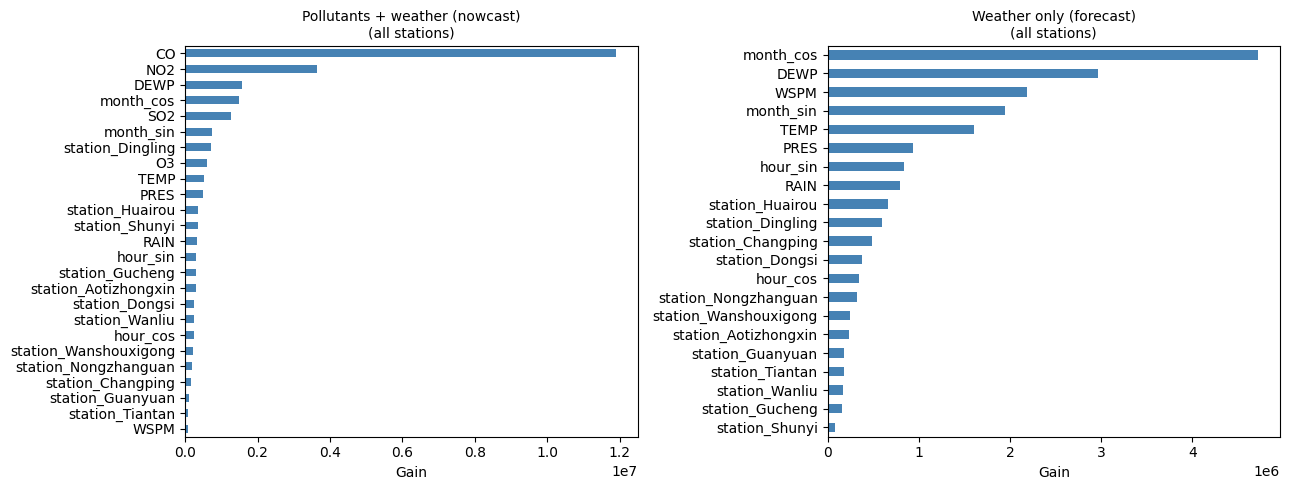

In [193]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, feature in zip(axes, FEATURE_SETS):
    split = splits[(feature, "All stations")]
    model = fitted_models[(feature, "All stations")]["regression"]["XGBoost"]
    gain_scores = model.get_booster().get_score(importance_type='gain')
    importances = pd.Series(gain_scores).reindex(split["X_train"].columns, fill_value=0).sort_values()

    importances.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_xlabel("Gain")
    ax.set_title(f"{feature}\n(all stations)", fontsize=10)

plt.tight_layout()
plt.show()

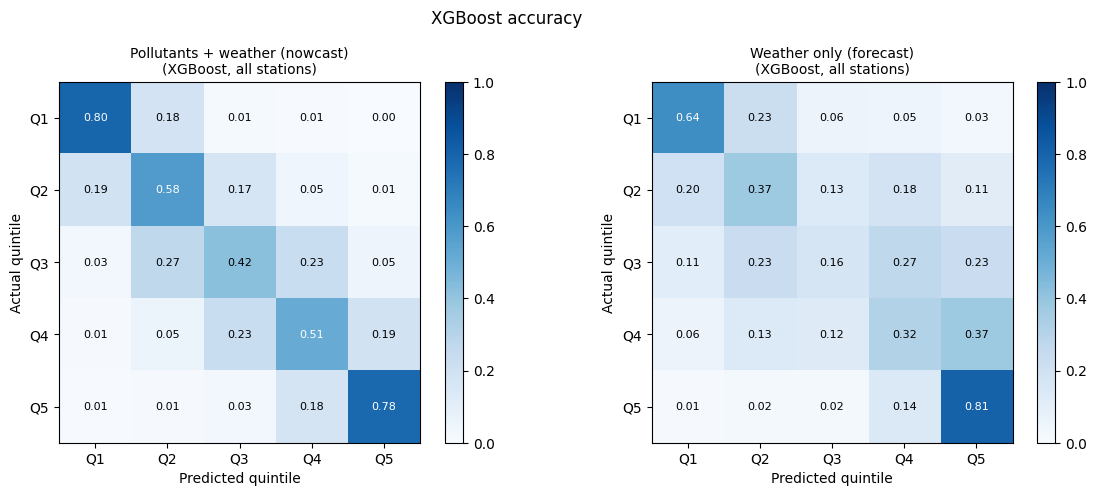

In [194]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, feature in zip(axes, FEATURE_SETS):
    key = (feature, "All stations")
    split = splits[key]
    model = fitted_models[key]["quintile classification"]["XGBoost"]
    label_encoder = fitted_models[key]["label_encoder"]

    y_test_enc = label_encoder.transform(split["y_test_cls"])
    preds = model.predict(split["X_test"])
    cm = confusion_matrix(y_test_enc, preds, normalize="true")

    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(label_encoder.classes_)))
    ax.set_xticklabels(label_encoder.classes_)
    ax.set_yticks(range(len(label_encoder.classes_)))
    ax.set_yticklabels(label_encoder.classes_)
    ax.set_xlabel("Predicted quintile")
    ax.set_ylabel("Actual quintile")
    ax.set_title(f"{feature}\n(XGBoost, all stations)", fontsize=10)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center",
                     color="white" if cm[i, j] > 0.5 else "black", fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle("XGBoost accuracy")
plt.tight_layout()
plt.show()

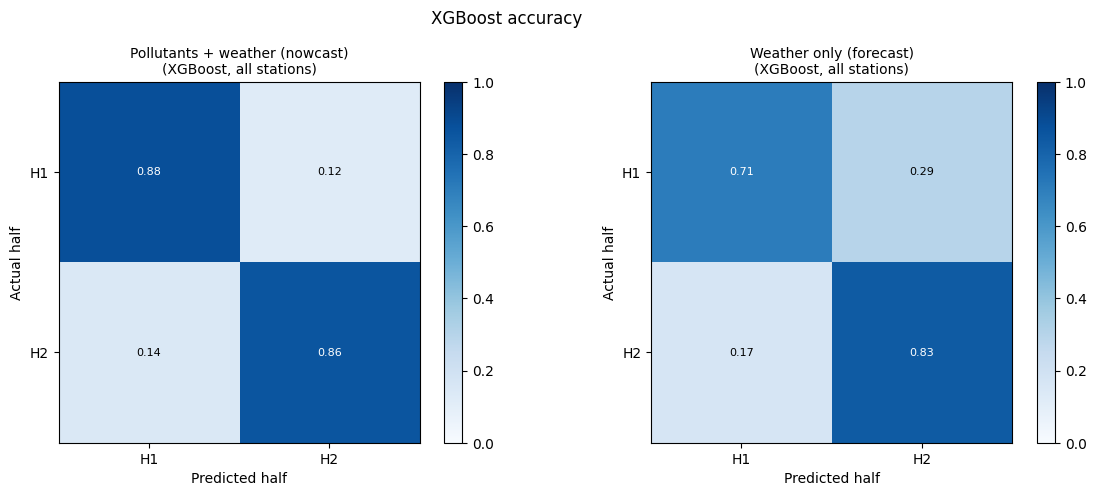

In [195]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, feature in zip(axes, FEATURE_SETS):
    key = (feature, "All stations")
    split = splits[key]
    model = fitted_models[key]["binary classification"]["XGBoost"]
    binary_label_encoder = fitted_models[key]["binary_label_encoder"]

    y_test_enc = binary_label_encoder.transform(split["y_test_binary"])
    preds = model.predict(split["X_test"])
    cm = confusion_matrix(y_test_enc, preds, normalize="true")

    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(binary_label_encoder.classes_)))
    ax.set_xticklabels(binary_label_encoder.classes_)
    ax.set_yticks(range(len(binary_label_encoder.classes_)))
    ax.set_yticklabels(binary_label_encoder.classes_)
    ax.set_xlabel("Predicted half")
    ax.set_ylabel("Actual half")
    ax.set_title(f"{feature}\n(XGBoost, all stations)", fontsize=10)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center",
                     color="white" if cm[i, j] > 0.5 else "black", fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle("XGBoost accuracy")
plt.tight_layout()
plt.show()  